# 05 — Model Development
Phase 6 (class imbalance) and Phase 7 (model development): build and compare 5 classifiers on a leakage-safe pipeline.

In [1]:
import sys, warnings
sys.path.append('../src')
warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix)

from preprocessing import (load_raw_data, basic_clean, encode_target, get_column_groups,
                            build_preprocessing_pipeline, get_feature_names)
from feature_engineering import engineer_features

RANDOM_STATE = 42
DROP = ["policy_number","insured_zip","incident_location","policy_bind_date","incident_date"]

df = load_raw_data('../data/raw/insurance_claims.csv')
df = basic_clean(df); df = encode_target(df)
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['fraud_reported'], random_state=RANDOM_STATE)
train_df = train_df.reset_index(drop=True); test_df = test_df.reset_index(drop=True)

train_fe, high_value_threshold = engineer_features(train_df)
test_fe, _ = engineer_features(test_df, high_value_threshold=high_value_threshold)
train_fe = train_fe.drop(columns=[c for c in DROP if c in train_fe.columns])
test_fe = test_fe.drop(columns=[c for c in DROP if c in test_fe.columns])
y_train = train_fe.pop('fraud_reported'); y_test = test_fe.pop('fraud_reported')

numeric_cols, categorical_cols = get_column_groups(pd.concat([train_fe, y_train.rename('fraud_reported')], axis=1))
preprocessor = build_preprocessing_pipeline(numeric_cols, categorical_cols)
X_train = preprocessor.fit_transform(train_fe); X_test = preprocessor.transform(test_fe)
if hasattr(X_train, 'toarray'): X_train, X_test = X_train.toarray(), X_test.toarray()
feature_names = get_feature_names(preprocessor)
print("Encoded feature count:", X_train.shape[1])

Encoded feature count: 174


## Class imbalance
Fraud rate in the training split is ~24.7%. Why this matters: with a moderately imbalanced target, a classifier can achieve high **accuracy** by simply predicting the majority class ("not fraud") most of the time, while catching almost no actual fraud. That's the opposite of what the business needs, so accuracy cannot be the primary metric (Phase 6 requirement) — precision, recall, F1, ROC-AUC and especially **PR-AUC** (precision-recall AUC, which is more informative than ROC-AUC under class imbalance) are used instead.

**Approach comparison:**
- *Class weights* (`class_weight='balanced'`): reweights the loss function, no synthetic data, cheap, but less effective when the minority class is small and complex.
- *Random undersampling*: throws away majority-class data — with only 1,000 rows total, this would discard useful legitimate-claim examples.
- *SMOTE* (Synthetic Minority Oversampling): generates synthetic minority-class examples by interpolating between real fraud cases. Chosen here because the dataset is small enough that discarding data (undersampling) is wasteful, and SMOTE tends to give tree ensembles more minority-class structure to learn from than class weights alone.

**Leakage control:** SMOTE is fit and applied to the **training split only**, after the split and after preprocessing — the test set is left in its true, real-world imbalanced state, since that's what production data will actually look like.

In [2]:
print("Train class distribution before SMOTE:", np.bincount(y_train))
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("Train class distribution after SMOTE: ", np.bincount(y_train_sm))

Train class distribution before SMOTE: [602 198]
Train class distribution after SMOTE:  [602 602]


## Five candidate models
Logistic Regression (interpretable baseline), Decision Tree (simple, explainable), Random Forest, XGBoost, and Gradient Boosting (the two strongest typical performers on tabular fraud data).

In [3]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, eval_metric='logloss', random_state=RANDOM_STATE, use_label_encoder=False),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

results = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    fitted_models[name] = model
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "PR_AUC": average_precision_score(y_test, y_proba),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
    })

results_df = pd.DataFrame(results).sort_values("PR_AUC", ascending=False).reset_index(drop=True)
results_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,TP,FP,TN,FN
0,Gradient Boosting,0.825,0.640,0.653,0.646,0.841,0.598,32,18,133,17
1,XGBoost,0.805,0.614,0.551,0.581,0.829,0.586,27,17,134,22
2,Random Forest,0.815,0.658,0.510,0.575,0.848,0.563,25,13,138,24
3,Decision Tree,0.810,0.604,0.653,0.627,0.752,0.540,32,21,130,17
4,Logistic Regression,0.810,0.604,0.653,0.627,0.808,0.519,32,21,130,17


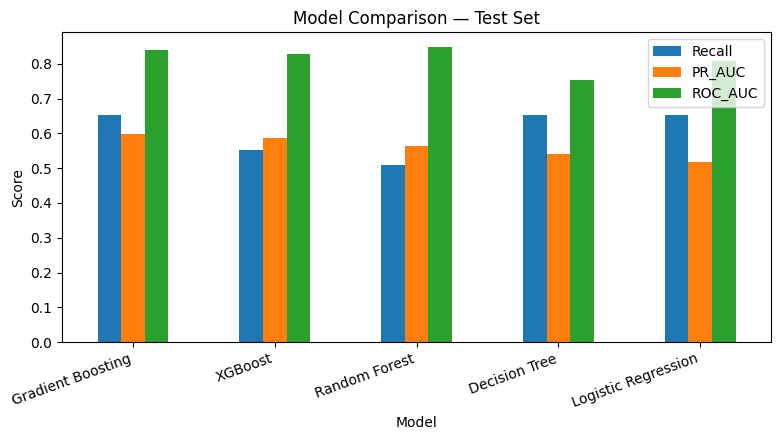

In [4]:
fig, ax = plt.subplots(figsize=(8,4.5))
results_df.set_index('Model')[['Recall','PR_AUC','ROC_AUC']].plot(kind='bar', ax=ax)
ax.set_title('Model Comparison — Test Set'); ax.set_ylabel('Score'); plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

## Phase 6 & 7 summary
- Training-set class imbalance (~25% fraud) was corrected with SMOTE on the training split only.
- All 5 required model families were trained under an identical pipeline and evaluated on the same untouched test set.
- Accuracy differences between models are small (~0.80–0.83) and not the deciding factor — **Recall and PR-AUC differ more meaningfully across models** and are what matters for the business objective; that comparison drives model selection in notebook 06.